# 03 RFM 用户分群

## 目标
- 基于 RFM 模型进行用户价值分群
- R (Recency): 最近一次购买距今天数
- F (Frequency): 购买频率
- M (Monetary): 购买金额（用购买次数近似）
- 使用 K-Means 聚类进行用户分群
- 可视化分群结果，标注高价值/流失风险用户

## RFM 模型说明
| 指标 | 含义 | 高分特征 |
|------|------|----------|
| R | 最近一次购买时间 | 越近越好 |
| F | 购买频率 | 越高越好 |
| M | 购买金额/次数 | 越高越好 |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'user_behavior_clean.csv')
df = pd.read_csv(DATA_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])

print(f'数据加载完成: {len(df):,} 条记录')

数据加载完成: 5,070,824 条记录


## 1. 计算 RFM 指标

In [4]:
# 筛选购买行为
buy_df = df[df['behavior_type'] == 'buy'].copy()
print(f'购买记录数: {len(buy_df):,}')
print(f'购买用户数: {buy_df["user_id"].nunique():,}')

# 设定参考日期（数据中最大日期 + 1天）
reference_date = buy_df['datetime'].max() + pd.Timedelta(days=1)
print(f'参考日期: {reference_date}')

购买记录数: 103,128
购买用户数: 34,149
参考日期: 2017-12-04 15:59:51


In [5]:
# 计算RFM
rfm = buy_df.groupby('user_id').agg(
    recency=('datetime', lambda x: (reference_date - x.max()).days),
    frequency=('item_id', 'count'),
    monetary=('item_id', 'nunique')  # 用购买的不同商品数近似金额
).reset_index()

print('=== RFM 统计描述 ===')
print(rfm.describe())
print()
print(f'RFM 用户数: {len(rfm):,}')

=== RFM 统计描述 ===
            user_id       recency     frequency      monetary
count  3.414900e+04  34149.000000  34149.000000  34149.000000
mean   5.098321e+05      3.553486      3.019942      2.883393
std    2.942878e+05      2.427607      3.012884      2.717712
min    2.000000e+01      1.000000      1.000000      1.000000
25%    2.566610e+05      1.000000      1.000000      1.000000
50%    5.082750e+05      3.000000      2.000000      2.000000
75%    7.628080e+05      5.000000      4.000000      4.000000
max    1.018011e+06      9.000000    175.000000    120.000000

RFM 用户数: 34,149


## 2. RFM 评分（五分位法）

In [6]:
# 使用五分位法进行评分
# R 越小越好（最近购买），所以反向评分
r_bins = pd.qcut(rfm['recency'], q=5, duplicates='drop')
rfm['R_score'] = (r_bins.cat.codes.max() - r_bins.cat.codes + 1).astype(int)

f_bins = pd.qcut(rfm['frequency'].rank(method='first'), q=5, duplicates='drop')
rfm['F_score'] = (f_bins.cat.codes + 1).astype(int)

m_bins = pd.qcut(rfm['monetary'].rank(method='first'), q=5, duplicates='drop')
rfm['M_score'] = (m_bins.cat.codes + 1).astype(int)

# 计算RFM总分
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('=== RFM 评分分布 ===')
print(rfm[['R_score', 'F_score', 'M_score', 'RFM_score']].describe())

=== RFM 评分分布 ===
            R_score       F_score       M_score     RFM_score
count  34149.000000  34149.000000  34149.000000  34149.000000
mean       2.978799      3.000000      3.000000      8.978799
std        1.115565      1.414255      1.414255      3.352782
min        1.000000      1.000000      1.000000      3.000000
25%        2.000000      2.000000      2.000000      6.000000
50%        3.000000      3.000000      3.000000      9.000000
75%        4.000000      4.000000      4.000000     12.000000
max        4.000000      5.000000      5.000000     14.000000


## 3. 用户分群

In [7]:
# 基于RFM总分进行分群
def segment_user(score):
    if score >= 13:
        return '高价值用户'
    elif score >= 10:
        return '潜力用户'
    elif score >= 7:
        return '一般用户'
    else:
        return '流失风险用户'

rfm['segment'] = rfm['RFM_score'].apply(segment_user)

# 分群统计
segment_stats = rfm.groupby('segment').agg(
    用户数=('user_id', 'count'),
    平均R=('recency', 'mean'),
    平均F=('frequency', 'mean'),
    平均M=('monetary', 'mean'),
    平均RFM分=('RFM_score', 'mean')
).round(2)

segment_stats['占比(%)'] = (segment_stats['用户数'] / segment_stats['用户数'].sum() * 100).round(2)

print('=== 用户分群统计 ===')
print(segment_stats)

=== 用户分群统计 ===
          用户数   平均R   平均F   平均M  平均RFM分  占比(%)
segment                                       
一般用户     8240  3.88  1.86  1.79    7.99  24.13
流失风险用户   9848  5.37  1.08  1.06    4.80  28.84
潜力用户     9897  2.56  3.27  3.14   11.02  28.98
高价值用户    6164  1.81  7.27  6.84   13.70  18.05


## 4. K-Means 聚类分析

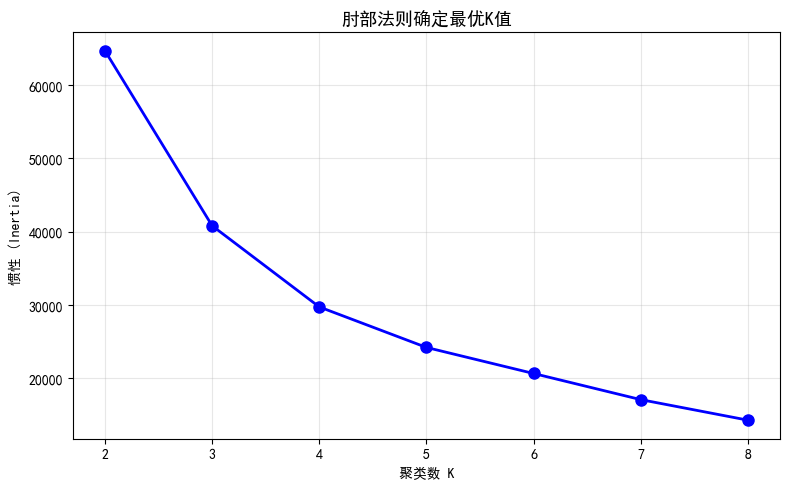

In [8]:
# 数据标准化
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

# 肘部法则确定最优K值
inertias = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('聚类数 K')
ax.set_ylabel('惯性 (Inertia)')
ax.set_title('肘部法则确定最优K值', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 使用K=4进行聚类
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# 聚类结果统计
cluster_stats = rfm.groupby('cluster').agg(
    用户数=('user_id', 'count'),
    平均R=('recency', 'mean'),
    平均F=('frequency', 'mean'),
    平均M=('monetary', 'mean')
).round(2)

print('=== K-Means 聚类结果 ===')
print(cluster_stats)

# 为每个聚类命名
cluster_names = {}
for c in range(K):
    r = cluster_stats.loc[c, '平均R']
    f = cluster_stats.loc[c, '平均F']
    if r < cluster_stats['平均R'].median() and f > cluster_stats['平均F'].median():
        cluster_names[c] = '高价值活跃用户'
    elif r < cluster_stats['平均R'].median():
        cluster_names[c] = '近期新用户'
    elif f > cluster_stats['平均F'].median():
        cluster_names[c] = '沉睡老用户'
    else:
        cluster_names[c] = '流失风险用户'

rfm['cluster_name'] = rfm['cluster'].map(cluster_names)
print('\n=== 聚类命名 ===')
for c, name in cluster_names.items():
    print(f'聚类 {c}: {name}')

=== K-Means 聚类结果 ===
           用户数   平均R    平均F    平均M
cluster                           
0        17885  2.20   2.22   2.15
1        10363  6.71   1.75   1.70
2          527  1.76  17.42  16.03
3         5374  2.16   6.74   6.33

=== 聚类命名 ===
聚类 0: 流失风险用户
聚类 1: 流失风险用户
聚类 2: 高价值活跃用户
聚类 3: 高价值活跃用户


## 5. 可视化

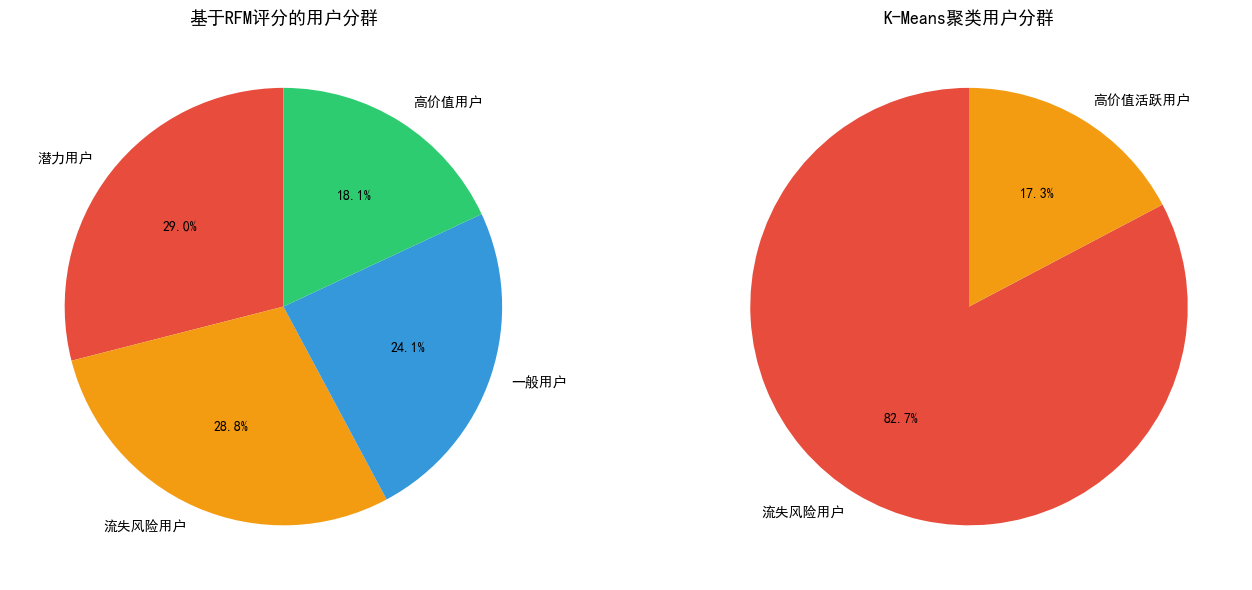

In [10]:
# RFM分群分布饼图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 基于评分的分群
segment_counts = rfm['segment'].value_counts()
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('基于RFM评分的用户分群', fontsize=13, fontweight='bold')

# K-Means聚类分布
cluster_counts = rfm['cluster_name'].value_counts()
axes[1].pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('K-Means聚类用户分群', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'rfm_segments.png'),
            dpi=150, bbox_inches='tight')
plt.show()

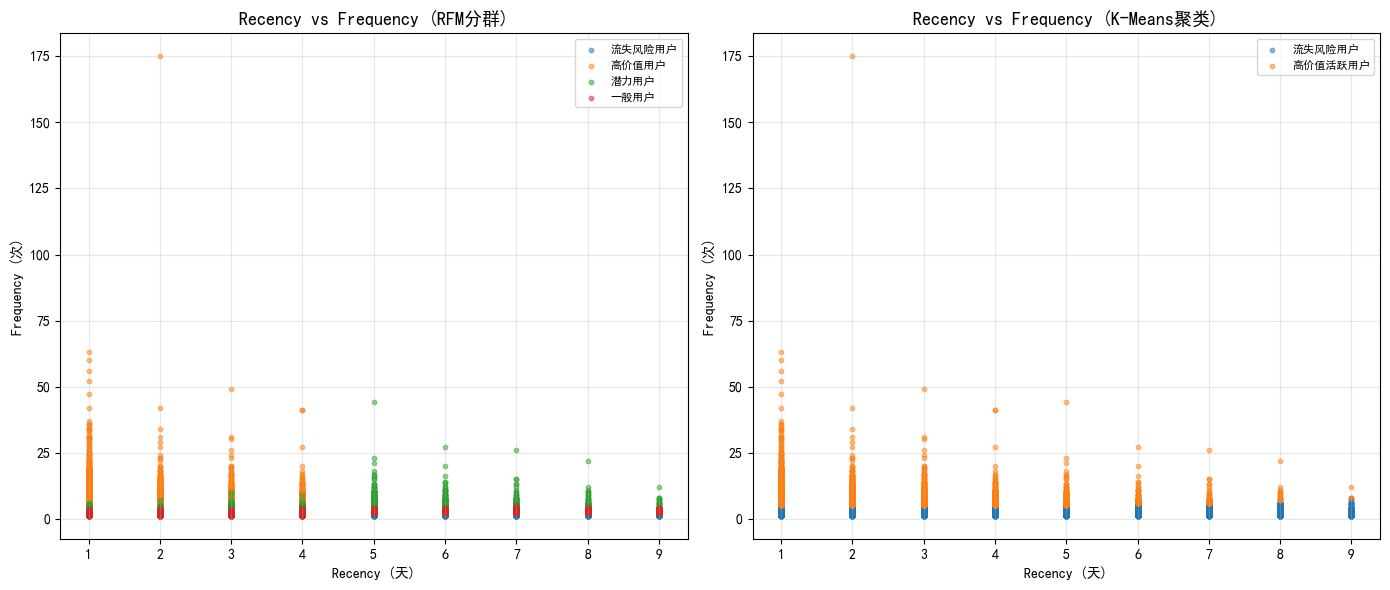

In [11]:
# R vs F 散点图（按分群着色）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 按RFM评分分群
for seg in rfm['segment'].unique():
    mask = rfm['segment'] == seg
    axes[0].scatter(rfm[mask]['recency'], rfm[mask]['frequency'],
                    alpha=0.5, s=10, label=seg)
axes[0].set_xlabel('Recency (天)')
axes[0].set_ylabel('Frequency (次)')
axes[0].set_title('Recency vs Frequency (RFM分群)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 按K-Means聚类
for name in rfm['cluster_name'].unique():
    mask = rfm['cluster_name'] == name
    axes[1].scatter(rfm[mask]['recency'], rfm[mask]['frequency'],
                    alpha=0.5, s=10, label=name)
axes[1].set_xlabel('Recency (天)')
axes[1].set_ylabel('Frequency (次)')
axes[1].set_title('Recency vs Frequency (K-Means聚类)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'rfm_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()

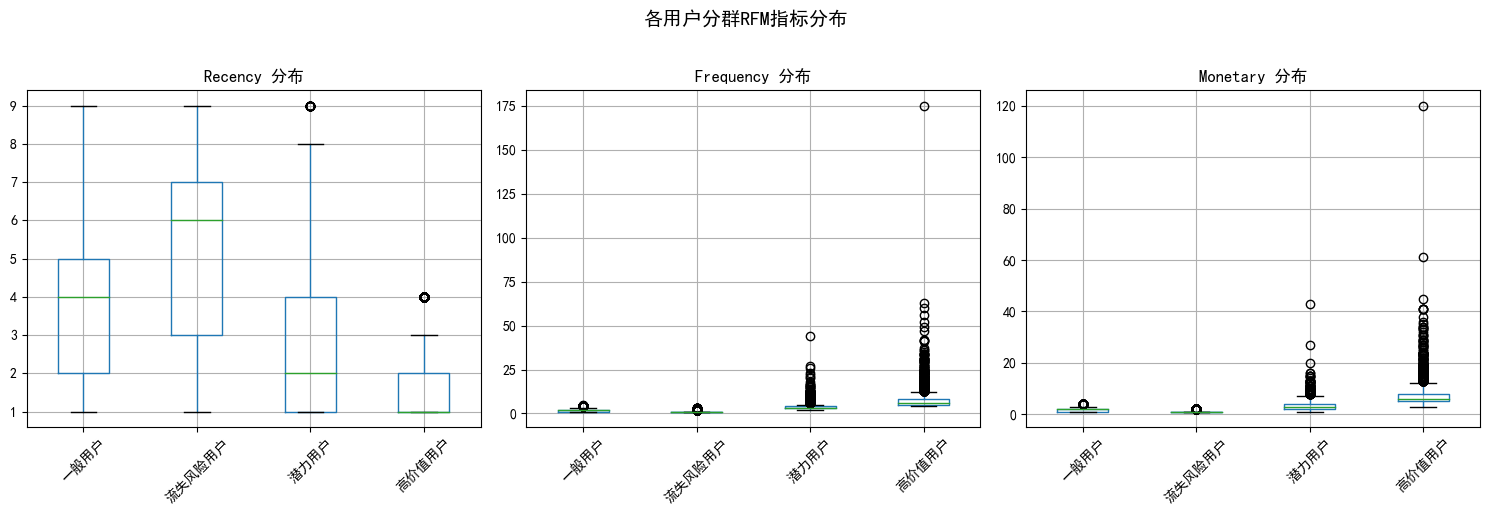

In [12]:
# 各分群RFM箱线图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, label) in enumerate([('recency', 'Recency'), ('frequency', 'Frequency'), ('monetary', 'Monetary')]):
    rfm.boxplot(column=col, by='segment', ax=axes[i])
    axes[i].set_title(f'{label} 分布', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('各用户分群RFM指标分布', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'rfm_boxplot.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. RFM 分群总结

### 分群策略
| 分群 | 特征 | 运营策略 |
|------|------|----------|
| 高价值用户 | R低、F高、M高 | VIP维护，专属优惠 |
| 潜力用户 | 中等水平 | 引导复购，提升频次 |
| 一般用户 | R高或F低 | 唤醒营销，限时促销 |
| 流失风险用户 | R高、F低、M低 | 召回活动，流失预警 |

### 业务建议
1. **高价值用户**：提供专属客服、VIP权益，保持忠诚度
2. **潜力用户**：通过个性化推荐提升购买频次
3. **一般用户**：发送优惠券、限时活动刺激消费
4. **流失风险用户**：进行流失预警，发送召回短信/推送